# ResNet-50 with Attention    
## Binary DR Detection (당뇨병성 망막병증 이진 분류 모델)
###dataset_1_ver4

### recall 기준의 best model 선정

---

**데이터 구조:**
- Train: 1,920 images
- Val: 640 images  
- Test: 640 images
- Label: 0 (No DR), 1 (DR)


In [2]:
# google mount
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 환경설정

import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torchvision.transforms as transforms
from torchvision import models
from PIL import Image

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# 재현성
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

🔧 Device: cuda
   GPU: NVIDIA L4


In [4]:
# ==============================================================================
# 2. 경로 및 CONFIG 설정
# ==============================================================================

# ⚠️ 본인의 경로로 수정!
BASE_DIR = '/content/drive/MyDrive/ColabNotebooks/RFMiD_A/EDA_2/dataset_1'
OUTPUT_DIR = '/content/drive/MyDrive/ColabNotebooks/RFMiD_A/model/ResNet50-Attention/ver4'

os.makedirs(OUTPUT_DIR, exist_ok=True)

# CSV 경로
TRAIN_CSV = os.path.join(BASE_DIR, 'manifest_train.csv')
VAL_CSV = os.path.join(BASE_DIR, 'manifest_val.csv')
TEST_CSV = os.path.join(BASE_DIR, 'manifest_test.csv')

# 이미지 디렉토리
TRAIN_IMG_DIR = os.path.join(BASE_DIR, 'train')
VAL_IMG_DIR = os.path.join(BASE_DIR, 'val')
TEST_IMG_DIR = os.path.join(BASE_DIR, 'test')

CONFIG = {
    # 모델
    'model_name': 'resnet50_attention',
    'pretrained': True,

    # 데이터
    'img_size': 512,
    'batch_size': 16,
    'num_workers': 4,

    # 학습
    'epochs': 50,
    'learning_rate': 5e-5,
    'weight_decay': 1e-3,

    # ✨ Recall 최적화
    'pos_weight': 2.5,
    'use_focal_loss': True,
    'focal_alpha': 0.25,
    'focal_gamma': 2.0,
    'use_class_balance': True,
    'use_mixup': True,
    'mixup_alpha': 0.3,
    'mixup_prob': 0.5,

    # ✨ Recall-aware early stopping
    'patience': 10,
    'min_recall': 0.85,
    'target_recall': 0.95,

    'max_grad_norm': 1.0,
    'save_best_only': True,

    # Checkpoint 설정
    'save_checkpoint': True,
    'checkpoint_metric': 'recall',  # ⭐ Recall 기준!
}

print("\n" + "="*80)
print("📋 CONFIG: ResNet-50 with Attention (Recall-Optimized)")
print("="*80)
for key, value in CONFIG.items():
    print(f"  {key:25s}: {value}")
print("="*80)



📋 CONFIG: ResNet-50 with Attention (Recall-Optimized)
  model_name               : resnet50_attention
  pretrained               : True
  img_size                 : 512
  batch_size               : 16
  num_workers              : 4
  epochs                   : 50
  learning_rate            : 5e-05
  weight_decay             : 0.001
  pos_weight               : 2.5
  use_focal_loss           : True
  focal_alpha              : 0.25
  focal_gamma              : 2.0
  use_class_balance        : True
  use_mixup                : True
  mixup_alpha              : 0.3
  mixup_prob               : 0.5
  patience                 : 10
  min_recall               : 0.85
  target_recall            : 0.95
  max_grad_norm            : 1.0
  save_best_only           : True
  save_checkpoint          : True
  checkpoint_metric        : recall


In [5]:
# ==============================================================================
# 3. Dataset
# ==============================================================================

class FundusDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

        print(f"\n📊 Dataset: {os.path.basename(csv_path)}")
        print(f"   Total: {len(self.df)}")
        print(f"   No DR: {(self.df['label']==0).sum()} ({(self.df['label']==0).sum()/len(self.df)*100:.1f}%)")
        print(f"   DR:    {(self.df['label']==1).sum()} ({(self.df['label']==1).sum()/len(self.df)*100:.1f}%)")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = str(row['img_id'])
        label = float(row['label'])

        img_path = os.path.join(self.img_dir, f"{img_id}.png")

        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (CONFIG['img_size'], CONFIG['img_size']))

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32), idx


In [6]:
# ==============================================================================
# 4. Transforms
# ==============================================================================

def get_transforms(mode='train'):
    if mode == 'train':
        return transforms.Compose([
            transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=20),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.15, hue=0.08),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            transforms.RandomErasing(p=0.2)
        ])
    else:
        return transforms.Compose([
            transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

In [7]:
# ==============================================================================
# 5. Mixup
# ==============================================================================

def mixup_data(x, y, alpha=0.3):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam


In [8]:
# ==============================================================================
# 6. Focal Loss
# ==============================================================================

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        return F_loss.mean()


In [9]:
# ==============================================================================
# 7. Attention Module
# ==============================================================================

class AttentionModule(nn.Module):
    def __init__(self, in_channels):
        super(AttentionModule, self).__init__()
        self.attention = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 8, kernel_size=1),
            nn.BatchNorm2d(in_channels // 8),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // 8, in_channels, kernel_size=1),
            nn.BatchNorm2d(in_channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        att = self.attention(x)
        return x * att

In [10]:
# ==============================================================================
# 8. Model: ResNet-50 with Attention
# ==============================================================================

class ResNet50Attention_BinaryDR(nn.Module):
    def __init__(self, pretrained=True):
        super(ResNet50Attention_BinaryDR, self).__init__()

        # ResNet-50 backbone
        resnet = models.resnet50(pretrained=pretrained)

        # Remove original FC layer
        self.features = nn.Sequential(*list(resnet.children())[:-2])

        # Attention module
        self.attention = AttentionModule(2048)

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        # Feature extraction
        x = self.features(x)

        # Attention
        x = self.attention(x)

        # Global pooling
        x = self.gap(x)
        x = x.view(x.size(0), -1)

        # Classification
        x = self.classifier(x)

        return x

In [11]:
# ==============================================================================
# 9. 학습 및 평가 함수
# ==============================================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device, config):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels, _ in tqdm(dataloader, desc='Training', leave=False):
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        # Mixup
        if config['use_mixup'] and np.random.random() < config['mixup_prob']:
            images, labels_a, labels_b, lam = mixup_data(images, labels, config['mixup_alpha'])
            outputs = model(images)
            loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config['max_grad_norm'])
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        all_preds.extend(torch.sigmoid(outputs).detach().cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

    epoch_loss = running_loss / len(dataloader.dataset)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    pred_binary = (all_preds > 0.5).astype(int)
    accuracy = accuracy_score(all_labels, pred_binary)
    recall = recall_score(all_labels, pred_binary, zero_division=0)
    auc = roc_auc_score(all_labels, all_preds)

    return epoch_loss, accuracy, recall, auc


def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels, _ in tqdm(dataloader, desc='Validation', leave=False):
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            all_preds.extend(torch.sigmoid(outputs).cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())

    epoch_loss = running_loss / len(dataloader.dataset)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    pred_binary = (all_preds > 0.5).astype(int)

    accuracy = accuracy_score(all_labels, pred_binary)
    precision = precision_score(all_labels, pred_binary, zero_division=0)
    recall = recall_score(all_labels, pred_binary, zero_division=0)
    f1 = f1_score(all_labels, pred_binary, zero_division=0)
    auc = roc_auc_score(all_labels, all_preds)

    cm = confusion_matrix(all_labels, pred_binary)

    return epoch_loss, accuracy, precision, recall, f1, auc, cm


In [12]:
# ==============================================================================
# 10. Checkpoint 저장/로드
# ==============================================================================

def save_checkpoint(model, optimizer, scheduler, epoch, metrics, config, filepath):
    """
    Checkpoint 저장
    """
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
        'val_recall': metrics['val_recall'],
        'val_auc': metrics['val_auc'],
        'val_accuracy': metrics['val_accuracy'],
        'val_precision': metrics['val_precision'],
        'val_f1': metrics['val_f1'],
        'config': config
    }

    torch.save(checkpoint, filepath)
    print(f"✅ Checkpoint saved: {filepath}")


def load_checkpoint(model, optimizer, scheduler, filepath):
    """
    Checkpoint 로드
    """
    if not os.path.exists(filepath):
        print(f"⚠️ Checkpoint not found: {filepath}")
        return 0, 0.0

    checkpoint = torch.load(filepath, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    if scheduler and checkpoint['scheduler_state_dict']:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    start_epoch = checkpoint['epoch'] + 1
    best_recall = checkpoint['val_recall']

    print(f"✅ Checkpoint loaded from epoch {checkpoint['epoch']}")
    print(f"   Val Recall: {best_recall:.4f}")
    print(f"   Val AUC: {checkpoint['val_auc']:.4f}")

    return start_epoch, best_recall



In [13]:
# ==============================================================================
# 11. 메인 학습 함수
# ==============================================================================

def train_model():
    print("\n" + "="*80)
    print("🚀 TRAINING START: ResNet-50 with Attention")
    print("="*80)

    # Datasets
    train_transform = get_transforms('train')
    val_transform = get_transforms('val')

    train_dataset = FundusDataset(TRAIN_CSV, TRAIN_IMG_DIR, train_transform)
    val_dataset = FundusDataset(VAL_CSV, VAL_IMG_DIR, val_transform)

    # Class-balanced sampler
    if CONFIG['use_class_balance']:
        train_df = pd.read_csv(TRAIN_CSV)
        class_counts = train_df['label'].value_counts().to_dict()
        class_weights = {0: 1.0/class_counts[0], 1: 1.0/class_counts[1]}
        sample_weights = [class_weights[int(label)] for label in train_df['label']]
        sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

        train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                                 sampler=sampler, num_workers=CONFIG['num_workers'])
        print(f"\n✅ Class-balanced sampling enabled")
        print(f"   No DR weight: {class_weights[0]:.4f}")
        print(f"   DR weight:    {class_weights[1]:.4f}")
    else:
        train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                                 shuffle=True, num_workers=CONFIG['num_workers'])

    val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'],
                           shuffle=False, num_workers=CONFIG['num_workers'])

    # Model
    model = ResNet50Attention_BinaryDR(pretrained=CONFIG['pretrained'])
    model = model.to(device)

    total_params = sum(p.numel() for p in model.parameters())
    print(f"\n✅ Model: {CONFIG['model_name']}")
    print(f"   Parameters: {total_params:,}")

    # Loss
    if CONFIG['use_focal_loss']:
        criterion = FocalLoss(alpha=CONFIG['focal_alpha'], gamma=CONFIG['focal_gamma'])
        print(f"\n✅ Loss: Focal Loss (alpha={CONFIG['focal_alpha']}, gamma={CONFIG['focal_gamma']})")
    else:
        train_df = pd.read_csv(TRAIN_CSV)
        pos_weight = torch.tensor([CONFIG['pos_weight']]).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        print(f"\n✅ Loss: Weighted BCE (pos_weight={CONFIG['pos_weight']})")

    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'],
                                  weight_decay=CONFIG['weight_decay'])

    # Scheduler (Recall 기준!)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

    # Training history
    history = {
        'train_loss': [], 'train_acc': [], 'train_recall': [], 'train_auc': [],
        'val_loss': [], 'val_acc': [], 'val_precision': [], 'val_recall': [], 'val_f1': [], 'val_auc': [],
        'lr': []
    }

    best_recall = 0.0
    patience_counter = 0

    # Checkpoint 경로
    checkpoint_path = os.path.join(OUTPUT_DIR, 'best_model_recall.pth')

    # Training loop
    for epoch in range(CONFIG['epochs']):
        print(f"\n{'='*80}")
        print(f"Epoch {epoch+1}/{CONFIG['epochs']}")
        print(f"{'='*80}")

        # Train
        train_loss, train_acc, train_recall, train_auc = train_one_epoch(
            model, train_loader, criterion, optimizer, device, CONFIG
        )

        # Validate
        val_loss, val_acc, val_prec, val_rec, val_f1, val_auc, val_cm = validate(
            model, val_loader, criterion, device
        )

        # LR update (Recall 기준!)
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_rec)

        # History
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_recall'].append(train_recall)
        history['train_auc'].append(train_auc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_precision'].append(val_prec)
        history['val_recall'].append(val_rec)
        history['val_f1'].append(val_f1)
        history['val_auc'].append(val_auc)
        history['lr'].append(current_lr)

        # Print results
        print(f"\n📊 Results:")
        print(f"   Train: Loss={train_loss:.4f}, Acc={train_acc:.4f}, Recall={train_recall:.4f}, AUC={train_auc:.4f}")
        print(f"   Val:   Loss={val_loss:.4f}, Acc={val_acc:.4f}, Recall={val_rec:.4f}, AUC={val_auc:.4f}")
        print(f"   Val:   Prec={val_prec:.4f}, F1={val_f1:.4f}")
        print(f"   LR: {current_lr:.6f}")

        # Confusion Matrix
        print(f"\n   Confusion Matrix:")
        print(f"   {val_cm}")
        tn, fp, fn, tp = val_cm.ravel()
        print(f"   TN={tn}, FP={fp}, FN={fn}, TP={tp}")

        # ⭐ Recall 기준 저장!
        recall_meets_target = val_rec >= CONFIG['min_recall']

        if recall_meets_target and val_rec > best_recall:
            best_recall = val_rec
            patience_counter = 0

            # Checkpoint 저장
            metrics = {
                'val_recall': val_rec,
                'val_auc': val_auc,
                'val_accuracy': val_acc,
                'val_precision': val_prec,
                'val_f1': val_f1
            }

            save_checkpoint(model, optimizer, scheduler, epoch, metrics, CONFIG, checkpoint_path)
            print(f"\n✅ Best model saved! (Recall: {best_recall:.4f}, AUC: {val_auc:.4f})")

        elif recall_meets_target:
            patience_counter += 1
            print(f"\n⏳ Recall OK but not improved. Patience: {patience_counter}/{CONFIG['patience']}")
        else:
            print(f"\n⚠️ Recall {val_rec:.4f} < target {CONFIG['min_recall']}")

        # Early stopping
        if patience_counter >= CONFIG['patience']:
            print(f"\n🛑 Early stopping at epoch {epoch+1}")
            break

    print("\n" + "="*80)
    print("✅ TRAINING COMPLETE")
    print("="*80)
    print(f"Best Validation Recall: {best_recall:.4f}")

    # Plot
    plot_history(history)

    return history, best_recall


def plot_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Loss
    axes[0, 0].plot(history['train_loss'], label='Train', linewidth=2)
    axes[0, 0].plot(history['val_loss'], label='Val', linewidth=2)
    axes[0, 0].set_title('Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Recall
    axes[0, 1].plot(history['train_recall'], label='Train', linewidth=2)
    axes[0, 1].plot(history['val_recall'], label='Val', linewidth=2)
    axes[0, 1].axhline(y=0.85, color='red', linestyle='--', label='Min Target (85%)')
    axes[0, 1].axhline(y=0.95, color='green', linestyle='--', label='Goal (95%)')
    axes[0, 1].set_title('Recall (Sensitivity)', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Recall')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim([0, 1.05])

    # AUC
    axes[1, 0].plot(history['train_auc'], label='Train', linewidth=2)
    axes[1, 0].plot(history['val_auc'], label='Val', linewidth=2)
    axes[1, 0].set_title('AUC', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('AUC')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim([0.5, 1.05])

    # LR
    axes[1, 1].plot(history['lr'], linewidth=2, color='red')
    axes[1, 1].set_title('Learning Rate', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
    print(f"\n✅ Training curves saved!")
    plt.show()


🚀 TRAINING START: ResNet-50 with Attention

📊 Dataset: manifest_train.csv
   Total: 1920
   No DR: 1544 (80.4%)
   DR:    376 (19.6%)

📊 Dataset: manifest_val.csv
   Total: 640
   No DR: 508 (79.4%)
   DR:    132 (20.6%)

✅ Class-balanced sampling enabled
   No DR weight: 0.0006
   DR weight:    0.0027
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 235MB/s]



✅ Model: resnet50_attention
   Parameters: 25,613,121

✅ Loss: Focal Loss (alpha=0.25, gamma=2.0)

Epoch 1/50



📊 Results:
   Train: Loss=0.0301, Acc=0.7245, Recall=0.7288, AUC=0.7897
   Val:   Loss=0.0164, Acc=0.8969, Recall=0.8636, AUC=0.9639
   Val:   Prec=0.7037, F1=0.7755
   LR: 0.000050

   Confusion Matrix:
   [[460  48]
 [ 18 114]]
   TN=460, FP=48, FN=18, TP=114
✅ Checkpoint saved: /content/drive/MyDrive/ColabNotebooks/RFMiD_A/model/ResNet50-Attention/ver4/best_model_recall.pth

✅ Best model saved! (Recall: 0.8636, AUC: 0.9639)

Epoch 2/50



📊 Results:
   Train: Loss=0.0241, Acc=0.7891, Recall=0.7725, AUC=0.8430
   Val:   Loss=0.0192, Acc=0.8812, Recall=0.8864, AUC=0.9616
   Val:   Prec=0.6573, F1=0.7548
   LR: 0.000050

   Confusion Matrix:
   [[447  61]
 [ 15 117]]
   TN=447, FP=61, FN=15, TP=117
✅ Checkpoint saved: /content/drive/MyDrive/ColabNotebooks/RFMiD_A/model/ResNet50-Attention/ver4/best_model_recall.pth

✅ Best model saved! (Recall: 0.8864, AUC: 0.9616)

Epoch 3/50


...


📊 Results:
   Train: Loss=0.0120, Acc=0.8432, Recall=0.8536, AUC=0.8774
   Val:   Loss=0.0156, Acc=0.9094, Recall=0.8788, AUC=0.9696
   Val:   Prec=0.7342, F1=0.8000
   LR: 0.000025

   Confusion Matrix:
   [[466  42]
 [ 16 116]]
   TN=466, FP=42, FN=16, TP=116

⏳ Recall OK but not improved. Patience: 7/10

Epoch 21/50



📊 Results:
   Train: Loss=0.0122, Acc=0.8547, Recall=0.8582, AUC=0.8893
   Val:   Loss=0.0140, Acc=0.9187, Recall=0.8636, AUC=0.9691
   Val:   Prec=0.7703, F1=0.8143
   LR: 0.000013

   Confusion Matrix:
   [[474  34]
 [ 18 114]]
   TN=474, FP=34, FN=18, TP=114

⏳ Recall OK but not improved. Patience: 8/10

Epoch 22/50



📊 Results:
   Train: Loss=0.0125, Acc=0.8354, Recall=0.8447, AUC=0.8893
   Val:   Loss=0.0139, Acc=0.9172, Recall=0.8636, AUC=0.9700
   Val:   Prec=0.7651, F1=0.8114
   LR: 0.000013

   Confusion Matrix:
   [[473  35]
 [ 18 114]]
   TN=473, FP=35, FN=18, TP=114

⏳ Recall OK but not improved. Patience: 9/10

Epoch 23/50



📊 Results:
   Train: Loss=0.0109, Acc=0.8719, Recall=0.8657, AUC=0.9130
   Val:   Loss=0.0131, Acc=0.9234, Recall=0.8333, AUC=0.9701
   Val:   Prec=0.8029, F1=0.8178
   LR: 0.000013

   Confusion Matrix:
   [[481  27]
 [ 22 110]]
   TN=481, FP=27, FN=22, TP=110

⚠️ Recall 0.8333 < target 0.85

Epoch 24/50



📊 Results:
   Train: Loss=0.0098, Acc=0.8708, Recall=0.8798, AUC=0.9044
   Val:   Loss=0.0141, Acc=0.9172, Recall=0.8712, AUC=0.9684
   Val:   Prec=0.7616, F1=0.8127
   LR: 0.000013

   Confusion Matrix:
   [[472  36]
 [ 17 115]]
   TN=472, FP=36, FN=17, TP=115

⏳ Recall OK but not improved. Patience: 10/10

🛑 Early stopping at epoch 24

✅ TRAINING COMPLETE
Best Validation Recall: 0.9621

✅ Training curves saved!


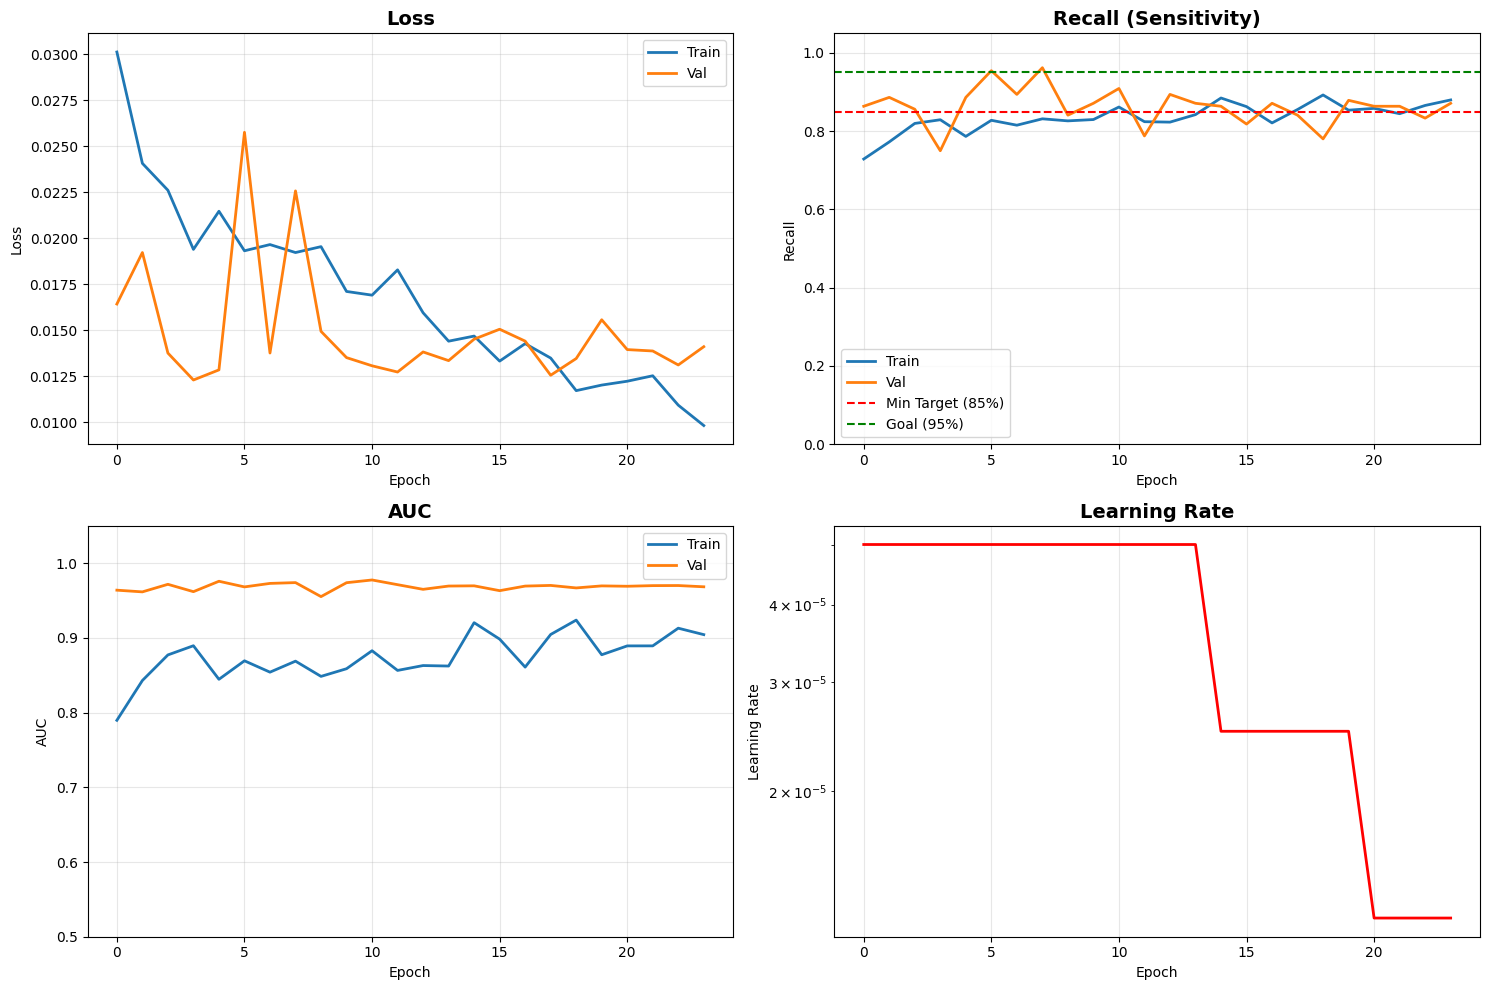


🎉 ALL DONE!
Best Recall: 0.9621
Model saved: /content/drive/MyDrive/ColabNotebooks/RFMiD_A/model/ResNet50-Attention/ver4/best_model_recall.pth


In [14]:
# ==============================================================================
# 12. 실행
# ==============================================================================

if __name__ == '__main__':
    history, best_recall = train_model()

    print("\n" + "="*80)
    print("🎉 ALL DONE!")
    print("="*80)
    print(f"Best Recall: {best_recall:.4f}")
    print(f"Model saved: {os.path.join(OUTPUT_DIR, 'best_model_recall.pth')}")
    print("="*80)

Device: cuda

📊 ResNet-50 with Attention Test Set Evaluation

📂 Test Dataset:
   Total: 640 samples
   No DR: 516 (80.6%)
   DR:    124 (19.4%)

📂 Loading Best Model...
✅ Model loaded successfully!

📊 Checkpoint Info:
   Epoch: 7
   Val Recall: 0.9621
   Val AUC: 0.9740
   Val Accuracy: 0.8562
   Val Precision: 0.5935

🚀 Evaluating on Test Set...


Testing: 100%|██████████| 40/40 [04:42<00:00,  7.06s/it]



📊 TEST SET PERFORMANCE
Accuracy:    0.8891
Precision:   0.6402
Recall:      0.9758 ✅ (Target achieved!)
F1 Score:    0.7732
Specificity: 0.8682
AUC:         0.9781

📊 Confusion Matrix:
[[448  68]
 [  3 121]]

TN=448, FP=68, FN=3, TP=121
False Negative Rate: 2.42% (3 patients missed)

📊 VALIDATION vs TEST COMPARISON
Metric          Validation      Test            Difference     
--------------------------------------------------------------------------------
Recall          0.9621          0.9758          +0.0137
AUC             0.9740          0.9781          +0.0041
Accuracy        0.8562          0.8891          +0.0328
Precision       0.5935          0.6402          +0.0468

✅ FINAL EVALUATION
✅ Recall ≥ 85%: FDA/WHO criteria met!
✅ Val-Test Recall gap < 5%: Good generalization!
✅ Val-Test AUC gap < 2%: Excellent generalization!

📈 Plotting results...

✅ Results plot saved!


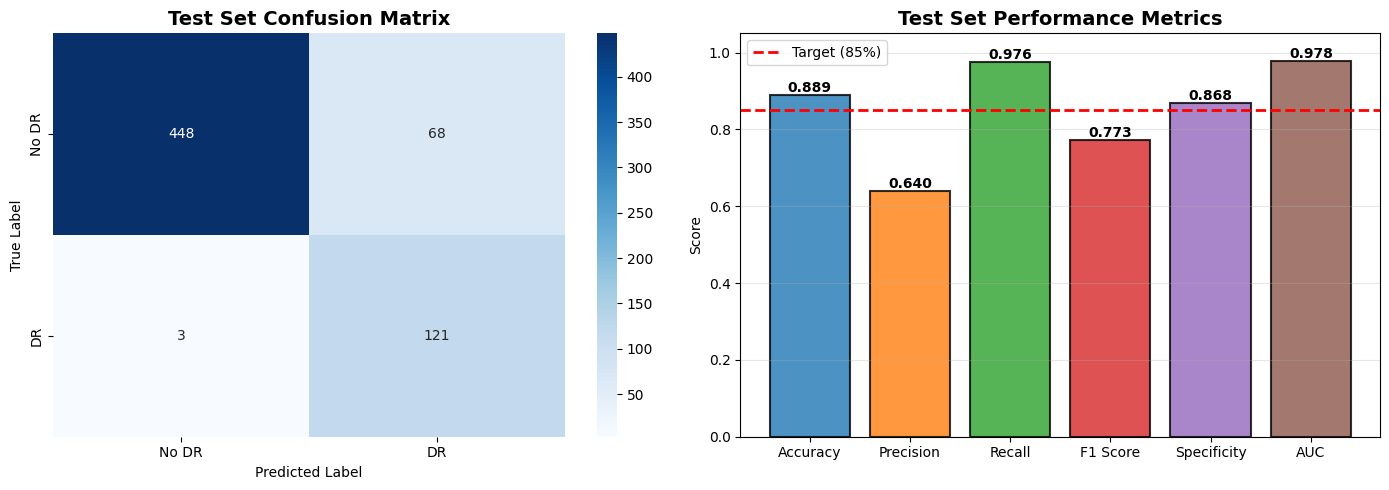

✅ Results saved: /content/drive/MyDrive/ColabNotebooks/RFMiD_A/model/ResNet50-Attention/ver4/test_results.csv

🎉 TEST EVALUATION COMPLETE!


In [16]:



import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ==============================================================================
# 1. 경로 설정
# ==============================================================================

# ⚠️ 본인의 경로로 수정!
BASE_DIR = '/content/drive/MyDrive/ColabNotebooks/RFMiD_A/EDA_2/dataset_1'
MODEL_DIR = '/content/drive/MyDrive/ColabNotebooks/RFMiD_A/model/ResNet50-Attention/ver4'

TEST_CSV = os.path.join(BASE_DIR, 'manifest_test.csv')
TEST_IMG_DIR = os.path.join(BASE_DIR, 'test')
MODEL_PATH = os.path.join(MODEL_DIR, 'best_model_recall.pth')

# ==============================================================================
# 2. Dataset & Model
# ==============================================================================

class FundusDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = str(row['img_id'])
        label = float(row['label'])

        img_path = os.path.join(self.img_dir, f"{img_id}.png")

        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (512, 512))

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)


class AttentionModule(nn.Module):
    def __init__(self, in_channels):
        super(AttentionModule, self).__init__()
        self.attention = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 8, kernel_size=1),
            nn.BatchNorm2d(in_channels // 8),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // 8, in_channels, kernel_size=1),
            nn.BatchNorm2d(in_channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        att = self.attention(x)
        return x * att


class ResNet50Attention_BinaryDR(nn.Module):
    def __init__(self, pretrained=True):
        super(ResNet50Attention_BinaryDR, self).__init__()

        # ResNet-50 backbone
        resnet = models.resnet50(pretrained=pretrained)

        # Remove original FC layer
        self.features = nn.Sequential(*list(resnet.children())[:-2])

        # Attention module
        self.attention = AttentionModule(2048)

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.attention(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# ==============================================================================
# 3. Test 평가 함수
# ==============================================================================

def evaluate_test_set(model, test_loader, device):
    """Test set 평가"""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Testing'):
            images = images.to(device)
            outputs = model(images).squeeze(1)
            probs = torch.sigmoid(outputs)

            all_preds.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    return all_preds, all_labels


def compute_metrics(labels, probs, threshold=0.5):
    """메트릭 계산"""
    preds = (probs >= threshold).astype(int)

    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)
    auc = roc_auc_score(labels, probs)

    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'specificity': specificity,
        'confusion_matrix': cm,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }


def plot_results(metrics, checkpoint_info, output_dir):
    """결과 시각화"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion Matrix
    cm = metrics['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['No DR', 'DR'], yticklabels=['No DR', 'DR'])
    axes[0].set_title('Test Set Confusion Matrix', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    # Metrics Bar Chart
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Specificity', 'AUC']
    metric_values = [
        metrics['accuracy'], metrics['precision'], metrics['recall'],
        metrics['f1'], metrics['specificity'], metrics['auc']
    ]

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    bars = axes[1].bar(metric_names, metric_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    axes[1].axhline(y=0.85, color='red', linestyle='--', linewidth=2, label='Target (85%)')
    axes[1].set_ylim([0, 1.05])
    axes[1].set_title('Test Set Performance Metrics', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Score')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)

    # 값 표시
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'test_results.png'), dpi=150, bbox_inches='tight')
    print(f"\n✅ Results plot saved!")
    plt.show()

# ==============================================================================
# 4. 메인 실행
# ==============================================================================

def main():
    print("\n" + "="*80)
    print("📊 ResNet-50 with Attention Test Set Evaluation")
    print("="*80)

    # 1. Test dataset 준비
    test_transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    test_dataset = FundusDataset(TEST_CSV, TEST_IMG_DIR, test_transform)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

    print(f"\n📂 Test Dataset:")
    print(f"   Total: {len(test_dataset)} samples")
    test_df = pd.read_csv(TEST_CSV)
    print(f"   No DR: {(test_df['label']==0).sum()} ({(test_df['label']==0).sum()/len(test_df)*100:.1f}%)")
    print(f"   DR:    {(test_df['label']==1).sum()} ({(test_df['label']==1).sum()/len(test_df)*100:.1f}%)")

    # 2. Best model 로드
    print(f"\n📂 Loading Best Model...")
    model = ResNet50Attention_BinaryDR(pretrained=False)
    checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()

    print(f"✅ Model loaded successfully!")
    print(f"\n📊 Checkpoint Info:")
    print(f"   Epoch: {checkpoint['epoch']}")
    print(f"   Val Recall: {checkpoint['val_recall']:.4f}")
    print(f"   Val AUC: {checkpoint['val_auc']:.4f}")
    print(f"   Val Accuracy: {checkpoint['val_accuracy']:.4f}")
    print(f"   Val Precision: {checkpoint['val_precision']:.4f}")

    # 3. Test 평가
    print(f"\n🚀 Evaluating on Test Set...")
    all_probs, all_labels = evaluate_test_set(model, test_loader, device)

    # 4. 메트릭 계산
    metrics = compute_metrics(all_labels, all_probs, threshold=0.5)

    # 5. 결과 출력
    print("\n" + "="*80)
    print("📊 TEST SET PERFORMANCE")
    print("="*80)
    print(f"Accuracy:    {metrics['accuracy']:.4f}")
    print(f"Precision:   {metrics['precision']:.4f}")
    print(f"Recall:      {metrics['recall']:.4f}", end="")
    if metrics['recall'] >= 0.85:
        print(" ✅ (Target achieved!)")
    else:
        print(f" ⚠️ (Target: ≥0.85)")
    print(f"F1 Score:    {metrics['f1']:.4f}")
    print(f"Specificity: {metrics['specificity']:.4f}")
    print(f"AUC:         {metrics['auc']:.4f}")

    print(f"\n📊 Confusion Matrix:")
    print(metrics['confusion_matrix'])
    print(f"\nTN={metrics['tn']}, FP={metrics['fp']}, FN={metrics['fn']}, TP={metrics['tp']}")
    print(f"False Negative Rate: {metrics['fn']/(metrics['fn']+metrics['tp'])*100:.2f}% ({metrics['fn']} patients missed)")

    # 6. Validation vs Test 비교
    print("\n" + "="*80)
    print("📊 VALIDATION vs TEST COMPARISON")
    print("="*80)
    print(f"{'Metric':<15} {'Validation':<15} {'Test':<15} {'Difference':<15}")
    print("-"*80)
    print(f"{'Recall':<15} {checkpoint['val_recall']:<15.4f} {metrics['recall']:<15.4f} {metrics['recall']-checkpoint['val_recall']:+.4f}")
    print(f"{'AUC':<15} {checkpoint['val_auc']:<15.4f} {metrics['auc']:<15.4f} {metrics['auc']-checkpoint['val_auc']:+.4f}")
    print(f"{'Accuracy':<15} {checkpoint['val_accuracy']:<15.4f} {metrics['accuracy']:<15.4f} {metrics['accuracy']-checkpoint['val_accuracy']:+.4f}")
    print(f"{'Precision':<15} {checkpoint['val_precision']:<15.4f} {metrics['precision']:<15.4f} {metrics['precision']-checkpoint['val_precision']:+.4f}")

    # 7. 평가
    recall_gap = abs(metrics['recall'] - checkpoint['val_recall'])
    auc_gap = abs(metrics['auc'] - checkpoint['val_auc'])

    print("\n" + "="*80)
    print("✅ FINAL EVALUATION")
    print("="*80)

    if metrics['recall'] >= 0.85:
        print("✅ Recall ≥ 85%: FDA/WHO criteria met!")
    else:
        print(f"⚠️ Recall < 85%: {0.85 - metrics['recall']:.2%} below target")

    if recall_gap < 0.05:
        print("✅ Val-Test Recall gap < 5%: Good generalization!")
    else:
        print(f"⚠️ Val-Test Recall gap ≥ 5%: Check for overfitting")

    if auc_gap < 0.02:
        print("✅ Val-Test AUC gap < 2%: Excellent generalization!")
    else:
        print(f"⚠️ Val-Test AUC gap ≥ 2%: Some performance drop")

    # 8. 시각화
    print(f"\n📈 Plotting results...")
    checkpoint_info = {
        'epoch': checkpoint['epoch'],
        'val_recall': checkpoint['val_recall'],
        'val_auc': checkpoint['val_auc']
    }
    plot_results(metrics, checkpoint_info, MODEL_DIR)

    # 9. 결과 저장
    results_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Specificity', 'AUC',
                   'TN', 'FP', 'FN', 'TP'],
        'Value': [metrics['accuracy'], metrics['precision'], metrics['recall'],
                  metrics['f1'], metrics['specificity'], metrics['auc'],
                  metrics['tn'], metrics['fp'], metrics['fn'], metrics['tp']]
    })

    results_path = os.path.join(MODEL_DIR, 'test_results.csv')
    results_df.to_csv(results_path, index=False)
    print(f"✅ Results saved: {results_path}")

    print("\n" + "="*80)
    print("🎉 TEST EVALUATION COMPLETE!")
    print("="*80)

if __name__ == '__main__':
    main()
